In [ ]:

import numpy as np
import pandas as pd


In [ ]:
data=pd.read_csv('/content/IEA Global EV Data 2024.csv', index_col=0)
display(data.head(10))
display(data.info())
display(data.shape)

,category,parameter,mode,powertrain,year,unit,value
region,,,,,,,
Australia,Historical,EV stock share,Cars,EV,2011,percent,0.00039
Australia,Historical,EV sales share,Cars,EV,2011,percent,0.00650
Australia,Historical,EV sales,Cars,BEV,2011,Vehicles,49.00000
Australia,Historical,EV stock,Cars,BEV,2011,Vehicles,49.00000
Australia,Historical,EV stock,Cars,BEV,2012,Vehicles,220.00000
Australia,Historical,EV sales,Cars,BEV,2012,Vehicles,170.00000
Australia,Historical,EV sales share,Cars,EV,2012,percent,0.03000
Australia,Historical,EV stock share,Cars,EV,2012,percent,0.00240
Australia,Historical,EV stock,Cars,PHEV,2012,Vehicles,80.00000


<class 'pandas.core.frame.DataFrame'>
Index: 12654 entries, Australia to World
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   category    12654 non-null  object 
 1   parameter   12654 non-null  object 
 2   mode        12654 non-null  object 
 3   powertrain  12654 non-null  object 
 4   year        12654 non-null  int64  
 5   unit        12654 non-null  object 
 6   value       12654 non-null  float64
dtypes: float64(1), int64(1), object(5)
memory usage: 790.9+ KB


None

(12654, 7)

In [ ]:
display(data.year.unique())

array([2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 2010, 2025, 2030, 2035])

# Data Loading and Initial Exploration




In [ ]:
# Reset the index to make 'region' a regular column
data.reset_index(inplace=True)

In [ ]:
display(data.head())
display(data.region.unique())

,region,category,parameter,mode,powertrain,year,unit,value
0,Australia,Historical,EV stock share,Cars,EV,2011,percent,0.00039
1,Australia,Historical,EV sales share,Cars,EV,2011,percent,0.00650
2,Australia,Historical,EV sales,Cars,BEV,2011,Vehicles,49.00000
3,Australia,Historical,EV stock,Cars,BEV,2011,Vehicles,49.00000
4,Australia,Historical,EV stock,Cars,BEV,2012,Vehicles,220.00000


array(['Australia', 'Austria', 'Belgium', 'Brazil', 'Bulgaria', 'Canada',
       'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus',
       'Czech Republic', 'Denmark', 'Estonia', 'EU27', 'Europe',
       'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland',
       'India', 'Indonesia', 'Ireland', 'Israel', 'Italy', 'Japan',
       'Korea', 'Latvia', 'Lithuania', 'Luxembourg', 'Mexico',
       'Netherlands', 'New Zealand', 'Norway', 'Poland', 'Portugal',
       'Rest of the world', 'Romania', 'Seychelles', 'Slovakia',
       'Slovenia', 'South Africa', 'Spain', 'Sweden', 'Switzerland',
       'Thailand', 'Turkiye', 'United Arab Emirates', 'United Kingdom',
       'USA', 'World'], dtype=object)

# Analyzing Electric Vehicle Data


In [ ]:
vehicles=data.loc[data['unit']=='Vehicles']
display(vehicles.head())
display(vehicles.shape)
display(vehicles.describe())

,region,category,parameter,mode,powertrain,year,unit,value
2,Australia,Historical,EV sales,Cars,BEV,2011,Vehicles,49.0
3,Australia,Historical,EV stock,Cars,BEV,2011,Vehicles,49.0
4,Australia,Historical,EV stock,Cars,BEV,2012,Vehicles,220.0
5,Australia,Historical,EV sales,Cars,BEV,2012,Vehicles,170.0
8,Australia,Historical,EV stock,Cars,PHEV,2012,Vehicles,80.0


(6842, 8)

,year,value
count,6842.000000,6.842000e+03
mean,2019.883221,7.503803e+05
std,5.352174,9.307153e+06
min,2010.000000,1.000000e-03
25%,2016.000000,6.725000e+01
50%,2020.000000,1.200000e+03
75%,2022.000000,2.200000e+04
max,2035.000000,4.400000e+08


### Distribution of Electric Vehicle Modes

T

,count
mode,
Cars,2975
Buses,1485
Vans,1449
Trucks,933


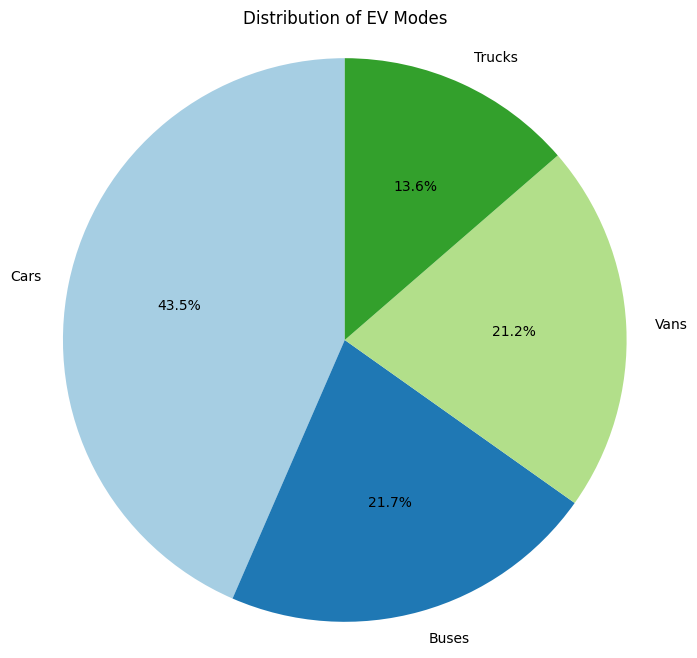

In [ ]:
mode=vehicles['mode'].value_counts()
display(mode)

import matplotlib.pyplot as plt

# Data for the pie chart
mode_counts = vehicles['mode'].value_counts()

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(mode_counts, labels=mode_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Distribution of EV Modes')
plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle.
plt.show()


# Data Processing



In [ ]:
# # Group the data by region and calculate the sum of the 'value' column
vehicles_countries_grouped = vehicles.groupby('region')['value'].sum()

# Convert the Series to a DataFrame
vehicles_countries_df = pd.DataFrame(vehicles_countries_grouped).reset_index()

# Rename the columns for clarity
vehicles_countries_df.columns = ['region', 'total_value']

# Drop the row where the region is 'World'
vehicles_countries_df = vehicles_countries_df[vehicles_countries_df['region'] != 'World']

# Display the DataFrame after dropping the row
print(vehicles_countries_df)


                  region   total_value
0              Australia  5.788320e+05
1                Austria  8.719660e+05
2                Belgium  1.687010e+06
3                 Brazil  2.649470e+05
4               Bulgaria  4.623000e+03
5                 Canada  2.416440e+06
6                  Chile  1.445800e+04
7                  China  1.148052e+09
8               Colombia  1.602300e+04
9             Costa Rica  2.763100e+04
10               Croatia  7.557000e+03
11                Cyprus  2.260000e+03
12        Czech Republic  3.430000e+04
13               Denmark  1.102561e+06
14                  EU27  3.324256e+07
15               Estonia  4.585000e+03
16                Europe  5.937754e+08
17               Finland  7.427230e+05
18                France  6.787772e+06
19               Germany  1.020111e+07
20                Greece  1.053560e+05
21               Hungary  4.203500e+04
22               Iceland  1.897660e+05
23                 India  6.341878e+07
24               Ireland 

# Data Visualization



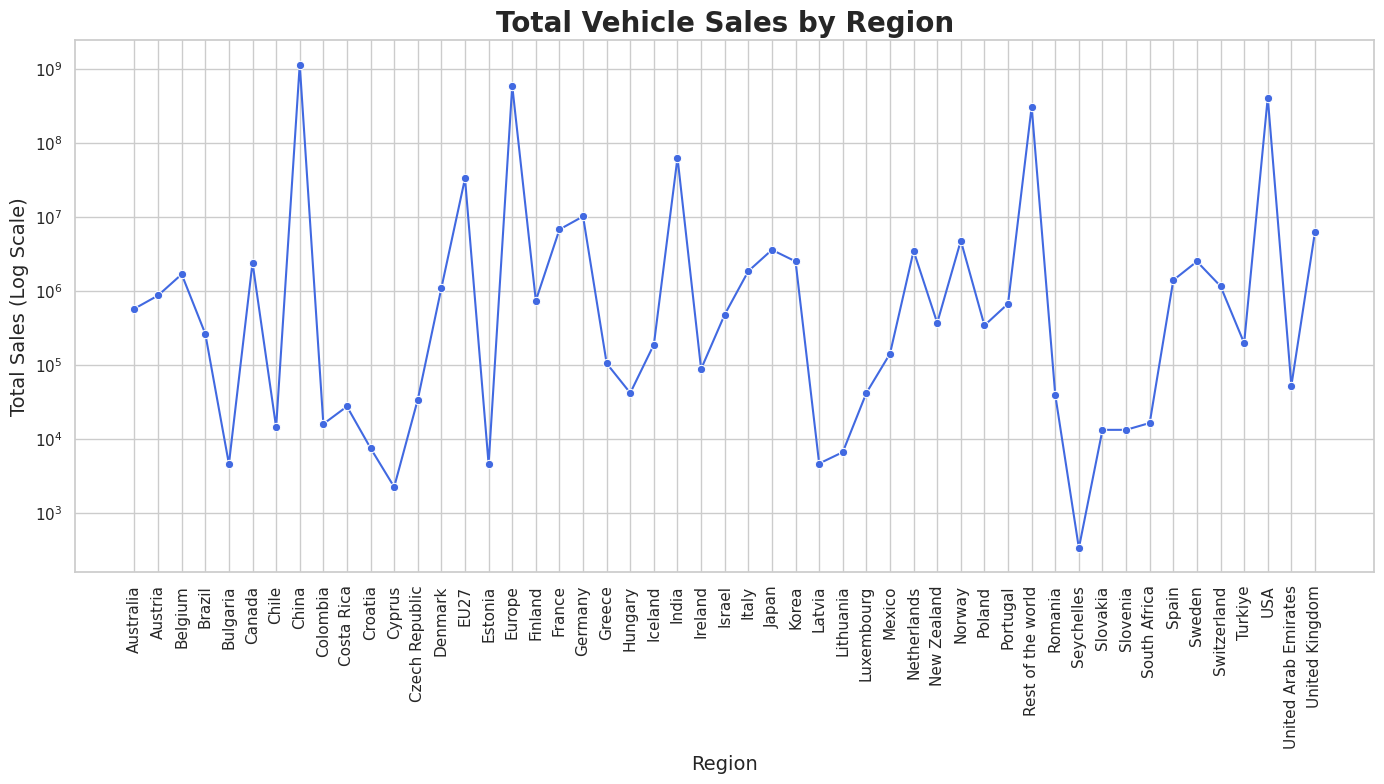

In [ ]:
pd.plotting.register_matplotlib_converters()
%matplotlib inline
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Create the figure and axis
plt.figure(figsize=(14, 8))

# Plot a line chart
sns.lineplot(data=vehicles_countries_df, x='region', y='total_value', marker='o', color='royalblue')

# Customize the plot
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.title('Total Vehicle Sales by Region', fontsize=20, fontweight='bold')
plt.xlabel('Region', fontsize=14)
plt.ylabel('Total Sales (Log Scale)', fontsize=14)

# Use logarithmic scale for the y-axis if values span a large range
plt.yscale('log')

# Show the plot
plt.tight_layout()
plt.show()


<ipython-input-13-5a058ee6fddf>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vehicles_countries_df, x='region', y='total_value', palette="viridis")


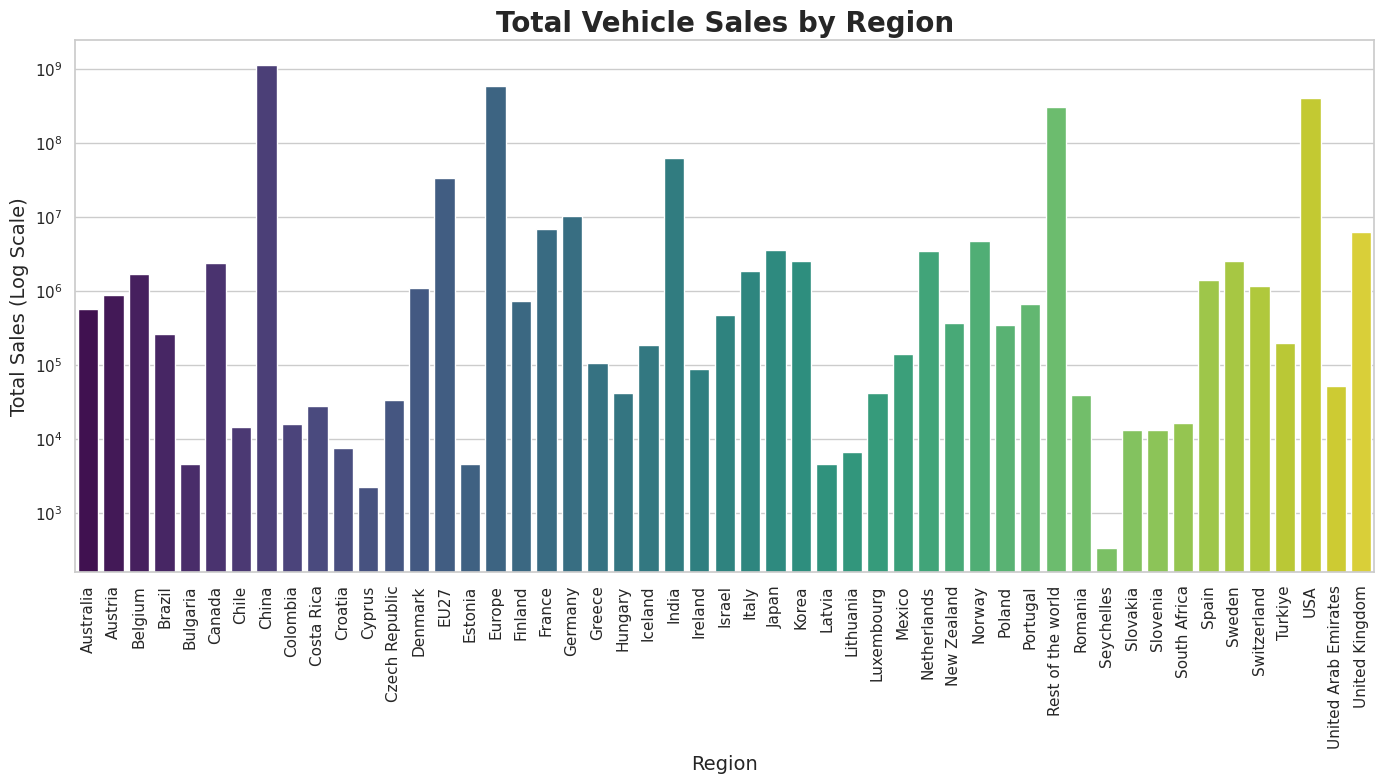

In [ ]:
# Set plot style
sns.set(style="whitegrid")

# Create the figure and axis
plt.figure(figsize=(14, 8))

# Plot a bar chart
sns.barplot(data=vehicles_countries_df, x='region', y='total_value', palette="viridis")

# Customize the plot
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.title('Total Vehicle Sales by Region', fontsize=20, fontweight='bold')
plt.xlabel('Region', fontsize=14)
plt.ylabel('Total Sales (Log Scale)', fontsize=14)

# Use logarithmic scale for the y-axis if values span a large range
plt.yscale('log')

# Show the plot
plt.tight_layout()
plt.show()

# Line and Bar Charts


In [ ]:
# Get the index of the row with the maximum value in 'total_value'
max_sales_index = vehicles_countries_df['total_value'].idxmax()

# Access the country (region) with the maximum EV sales
best_seller_country = vehicles_countries_df.loc[max_sales_index, 'region']

# Sort the DataFrame by 'total_value' in descending order and select the top 10 countries
top_10_countries = vehicles_countries_df.nlargest(10, 'total_value')

# Display the result
display(top_10_countries[['region', 'total_value']])



,region,total_value
7,China,1.148052e+09
16,Europe,5.937754e+08
48,USA,4.112801e+08
38,Rest of the world,3.089968e+08
23,India,6.341878e+07
14,EU27,3.324256e+07
19,Germany,1.020111e+07
18,France,6.787772e+06
50,United Kingdom,6.283637e+06
35,Norway,4.793634e+06


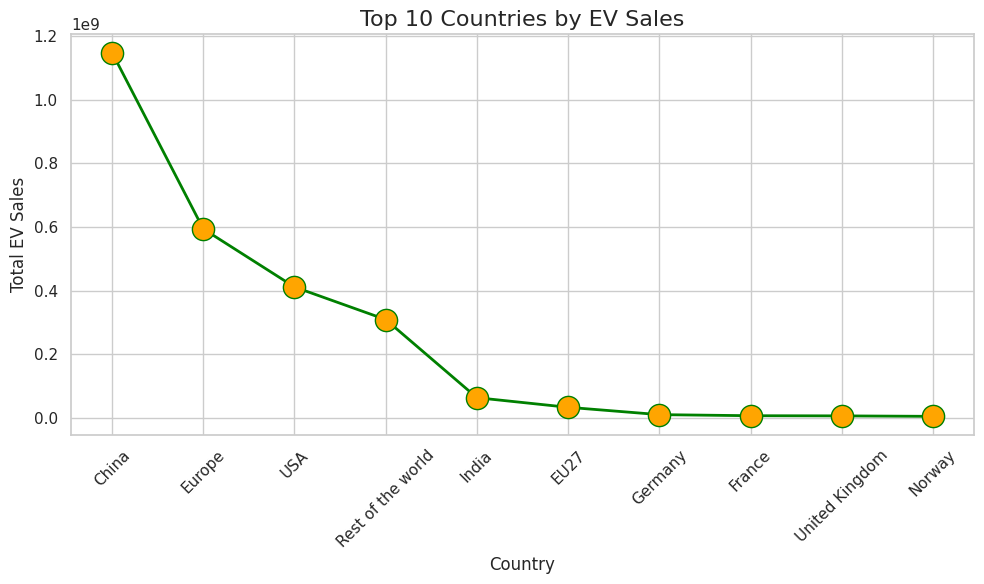

In [ ]:
# Set up the plot size and theme
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Sort the data to make the line chart look nice
sorted_top_10 = top_10_countries.sort_values('total_value', ascending=False)

# Plot a line chart with custom colors and larger markers
plt.plot(
    sorted_top_10['region'],
    sorted_top_10['total_value'],
    marker='o',
    color='green',           # Set line color to green
    markerfacecolor='orange', # Set marker color to orange
    linestyle='-',
    linewidth=2,
    markersize=16             # Increase marker size
)

# Add labels and title
plt.title('Top 10 Countries by EV Sales', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total EV Sales', fontsize=12)

# Rotate x-ticks for better readability
plt.xticks(rotation=45)

# Display the chart
plt.tight_layout()
plt.show()


# Line Chart on Countries Selling the Most EVs


In [ ]:
# Get the index of the row with the minimum value in 'total_value'
min_sales_index = vehicles_countries_df['total_value'].idxmin()

# Access the country (region) with the minimum EV sales
least_country = vehicles_countries_df.loc[min_sales_index, 'region']

# Sort the DataFrame by 'total_value' in descending order and select the bottom 10 countries
bottom_10_countries = vehicles_countries_df.nsmallest(10, 'total_value')

# Display the result
display(bottom_10_countries[['region', 'total_value']])

,region,total_value
40,Seychelles,338.0
11,Cyprus,2260.0
15,Estonia,4585.0
4,Bulgaria,4623.0
29,Latvia,4687.0
30,Lithuania,6673.0
10,Croatia,7557.0
41,Slovakia,13351.0
42,Slovenia,13363.0
6,Chile,14458.0


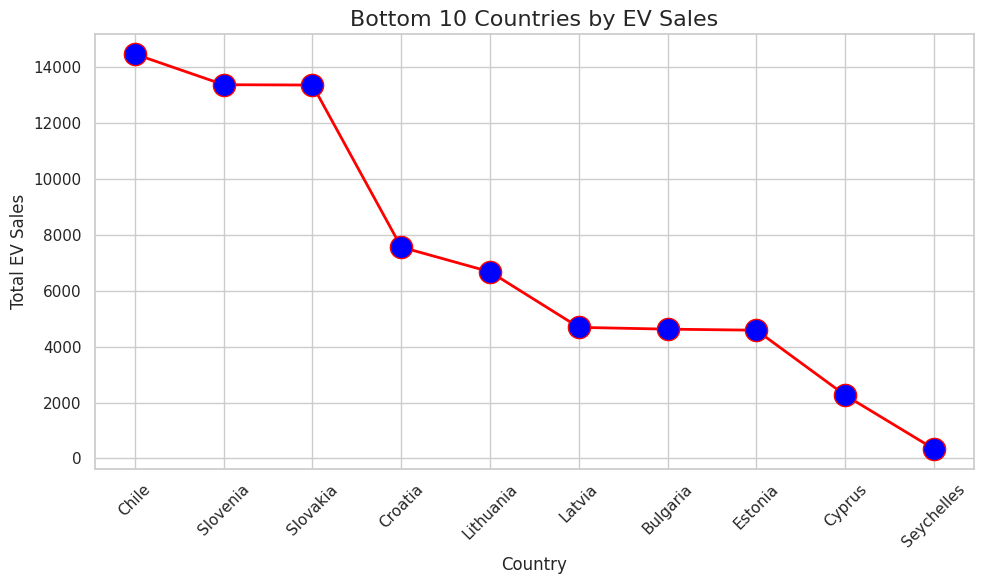

In [ ]:
# Set up the plot size and theme
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Sort the data to make the line chart look nice
sorted_top_10 = bottom_10_countries.sort_values('total_value', ascending=False)

# Plot a line chart with custom colors and larger markers
plt.plot(
    sorted_top_10['region'],
    sorted_top_10['total_value'],
    marker='o',
    color='red',           # Set line color to green
    markerfacecolor='blue', # Set marker color to orange
    linestyle='-',
    linewidth=2,
    markersize=16             # Increase marker size
)

# Add labels and title
plt.title('Bottom 10 Countries by EV Sales', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total EV Sales', fontsize=12)

# Rotate x-ticks for better readability
plt.xticks(rotation=45)

# Display the chart
plt.tight_layout()
plt.show()


# Line Chart on Countries Selling the Least EVs



In [ ]:
# Get the top 5 selling countries
top_5_countries = vehicles_countries_df.nlargest(5, 'total_value')

# Get the bottom 5 selling countries
bottom_5_countries = vehicles_countries_df.nsmallest(5, 'total_value')

# Concatenate the top 5 and bottom 5 countries into a new DataFrame
top_and_bottom_countries = pd.concat([top_5_countries, bottom_5_countries])

# Display the result
display(top_and_bottom_countries[['region', 'total_value']])


,region,total_value
7,China,1.148052e+09
16,Europe,5.937754e+08
48,USA,4.112801e+08
38,Rest of the world,3.089968e+08
23,India,6.341878e+07
40,Seychelles,3.380000e+02
11,Cyprus,2.260000e+03
15,Estonia,4.585000e+03
4,Bulgaria,4.623000e+03
29,Latvia,4.687000e+03


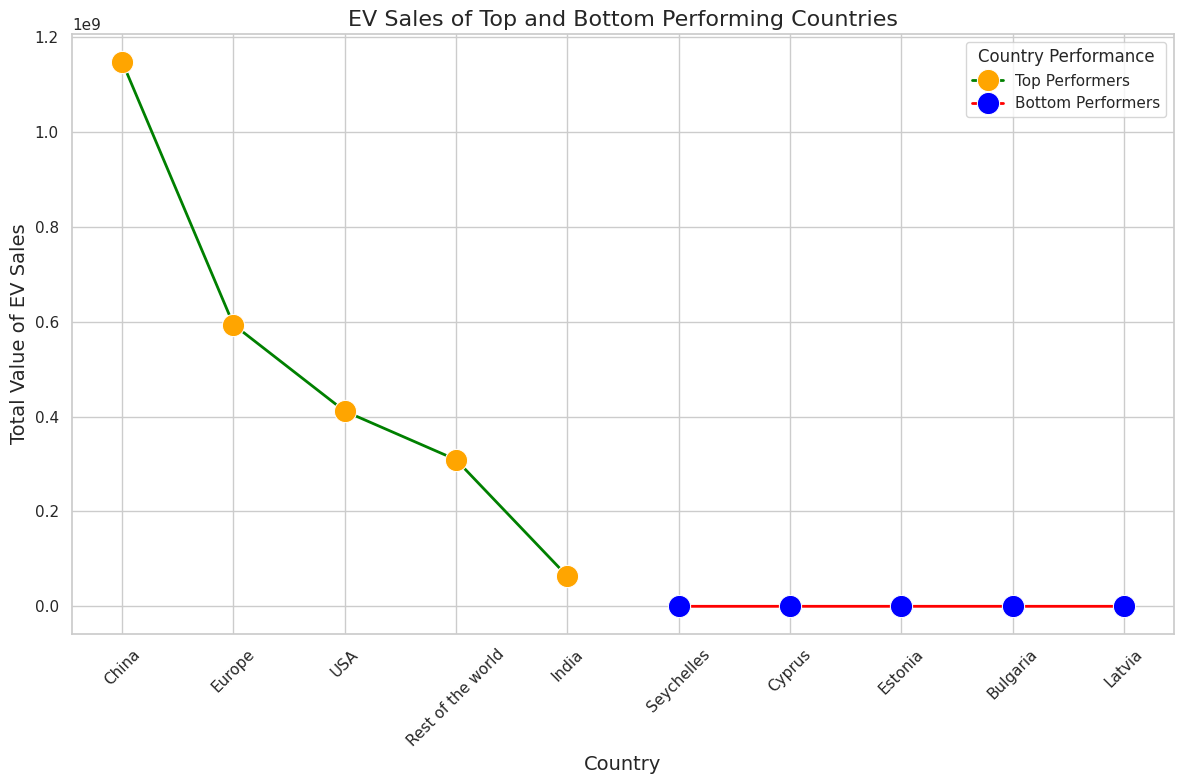

In [ ]:
# Separate top and bottom countries
top_countries = top_and_bottom_countries.iloc[:5]
bottom_countries = top_and_bottom_countries.iloc[5:]

# Create the plot
plt.figure(figsize=(12, 8))

# Plot top countries in one color (e.g., blue)
sns.lineplot(data=top_countries, x='region', y='total_value', marker='o', color='green', markerfacecolor='orange', markersize=16, label='Top Performers', linewidth=2)

# Plot bottom countries in another color (e.g., red)
sns.lineplot(data=bottom_countries, x='region', y='total_value', marker='o', color='red', markerfacecolor='blue', markersize=16, label='Bottom Performers', linewidth=2)

# Customizing the plot
plt.title('EV Sales of Top and Bottom Performing Countries', fontsize=16)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Total Value of EV Sales', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Country Performance')

# Show the plot
plt.tight_layout()
plt.show()


# Grouping by Continent

To facilitate further analysis, a continent mapping is created through a dictionary (continent_map), which manually assigns each country or region to its respective continent (e.g., Australia to Oceania, China to Asia). This map is then applied to the vehicles_countries_df dataframe, creating a new 'continent' column where each country is now associated with its continent.

Next, the code performs grouping by continent using the .groupby() function, summing the total EV sales (total_value) for each continent. This aggregated data is stored in the continent_totals dataframe, with the column names modified to clarify the data: continent and total_sales.

The final result, continent_totals, shows the total EV sales for each continent. Asia leads with over 1.2 billion sales, followed by Europe with 671 million, and North America with 413 million. Smaller regions like Oceania and South America show more modest totals, while the 'Other' category represents 308 million sales across the rest of the world.

In [ ]:
# Current dataframe, but we drop 'World'
vehicles_countries_df = pd.DataFrame({
    'region': ['Australia', 'Austria', 'Belgium', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia',
               'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'EU27', 'Estonia', 'Europe',
               'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'India', 'Ireland', 'Israel',
               'Italy', 'Japan', 'Korea', 'Latvia', 'Lithuania', 'Luxembourg', 'Mexico', 'Netherlands',
               'New Zealand', 'Norway', 'Poland', 'Portugal', 'Rest of the world', 'Romania', 'Seychelles',
               'Slovakia', 'Slovenia', 'South Africa', 'Spain', 'Sweden', 'Switzerland', 'Turkiye', 'USA',
               'United Arab Emirates', 'United Kingdom'],
    'total_value': [578832, 871966, 1687010, 264947, 4623, 2416440, 14458, 1148052000, 16023, 27631, 7557,
                    2260, 34300, 1102561, 33242560, 4585, 593775400, 742723, 6787772, 10201110, 105356,
                    42035, 189766, 63418780, 88570, 482187, 1860044, 3603756, 2516838, 4687, 6673, 42100,
                    142591, 3488004, 371462, 4793634, 343287, 674996, 308996800, 39488, 338, 13351, 13363,
                    16533, 1403419, 2509214, 1165185, 198338, 411280100, 52804, 6283637]
})

# Manually map each country/region to its continent
continent_map = {
    'Australia': 'Oceania', 'Austria': 'Europe', 'Belgium': 'Europe', 'Brazil': 'South America',
    'Bulgaria': 'Europe', 'Canada': 'North America', 'Chile': 'South America', 'China': 'Asia',
    'Colombia': 'South America', 'Costa Rica': 'North America', 'Croatia': 'Europe', 'Cyprus': 'Europe',
    'Czech Republic': 'Europe', 'Denmark': 'Europe', 'EU27': 'Europe', 'Estonia': 'Europe', 'Europe': 'Europe',
    'Finland': 'Europe', 'France': 'Europe', 'Germany': 'Europe', 'Greece': 'Europe', 'Hungary': 'Europe',
    'Iceland': 'Europe', 'India': 'Asia', 'Ireland': 'Europe', 'Israel': 'Asia', 'Italy': 'Europe',
    'Japan': 'Asia', 'Korea': 'Asia', 'Latvia': 'Europe', 'Lithuania': 'Europe', 'Luxembourg': 'Europe',
    'Mexico': 'North America', 'Netherlands': 'Europe', 'New Zealand': 'Oceania', 'Norway': 'Europe',
    'Poland': 'Europe', 'Portugal': 'Europe', 'Rest of the world': 'Other', 'Romania': 'Europe',
    'Seychelles': 'Africa', 'Slovakia': 'Europe', 'Slovenia': 'Europe', 'South Africa': 'Africa',
    'Spain': 'Europe', 'Sweden': 'Europe', 'Switzerland': 'Europe', 'Turkiye': 'Europe', 'USA': 'North America',
    'United Arab Emirates': 'Asia', 'United Kingdom': 'Europe'
}

# Add a 'continent' column to the dataframe
vehicles_countries_df['continent'] = vehicles_countries_df['region'].map(continent_map)

# Group by 'continent' and sum the total_value
continent_totals = vehicles_countries_df.groupby('continent')['total_value'].sum().reset_index()

# Rename columns for clarity
continent_totals.columns = ['continent', 'total_sales']

# Display the result
print(continent_totals)


       continent  total_sales
0         Africa        16871
1           Asia   1218126365
2         Europe    671729574
3  North America    413866762
4        Oceania       950294
5          Other    308996800
6  South America       295428


In [ ]:
# Filter the original dataframe for regions categorized as 'Other'
other_countries = vehicles_countries_df[vehicles_countries_df['continent'] == 'Other']

# Display the result
display(other_countries[['region', 'total_value']])

,region,total_value
38,Rest of the world,308996800


In [ ]:
import folium
from folium.plugins import MarkerCluster
from folium.plugins import HeatMap

# Sample coordinates for the center of the map
map_center = [20, 0]  # Adjust to center the map
m = folium.Map(location=map_center, zoom_start=2)

# Sample data - replace this with your actual continent totals and coordinates
continent_data = {
    'Africa': {'total_sales': 16871, 'coords': [1.0, 20.0]},  # Sample coordinates
    'Asia': {'total_sales': 1218126365, 'coords': [34.0, 100.0]},
    'Europe': {'total_sales': 671729574, 'coords': [48.0, 10.0]},
    'North America': {'total_sales': 413866762, 'coords': [37.0, -95.0]},
    'Oceania': {'total_sales': 950294, 'coords': [-25.0, 135.0]},
    'South America': {'total_sales': 295428, 'coords': [-15.0, -60.0]},
    'Other': {'total_sales': 2829116800, 'coords': [0.0, 0.0]}  # Dummy location
}

# Prepare data for heatmap and clustering
heat_data = []
marker_cluster = MarkerCluster().add_to(m)

# Add markers and prepare data for the heatmap
for continent, info in continent_data.items():
    # Marker for clustering
    folium.Marker(
        location=info['coords'],
        popup=f"{continent}: {info['total_sales']}",
        icon=folium.Icon(color='blue' if continent != 'Other' else 'red')
    ).add_to(marker_cluster)

    # Add to heatmap data
    heat_data.append(info['coords'] + [info['total_sales']])  # Adding sales value as weight

# Create heatmap
heatmap = HeatMap(heat_data, name='Sales Heatmap', radius=20).add_to(m)

# Add Layer Control
folium.LayerControl().add_to(m)

# Display the map
m
